In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 2. Carga y exploración
df = pd.read_csv('mnist_train.csv')
print(f"Dimensiones: {df.shape}")
print("Nulos:", df.isnull().sum().sum())

Dimensiones: (55000, 785)
Nulos: 0


In [3]:
# 3. Preparación X e y
X = df.drop('label', axis=1)
y = df['label']

# 4. División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# 5 y 6. Entrenamiento con 3 profundidades
profundidades = [5, 10, 20]
resultados = []

for d in profundidades:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    # Predicciones
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    resultados.append({'Profundidad': d, 'Train': train_acc, 'Test': test_acc})
    print(f"Profundidad {d}: Train={train_acc:.4f}, Test={test_acc:.4f}")

# 7. Tabla
df_res = pd.DataFrame(resultados)
display(df_res)

Profundidad 5: Train=0.6549, Test=0.6566
Profundidad 10: Train=0.9055, Test=0.8528
Profundidad 20: Train=0.9958, Test=0.8647


,Profundidad,Train,Test
0,5,0.654932,0.656636
1,10,0.905477,0.852818
2,20,0.995795,0.864727


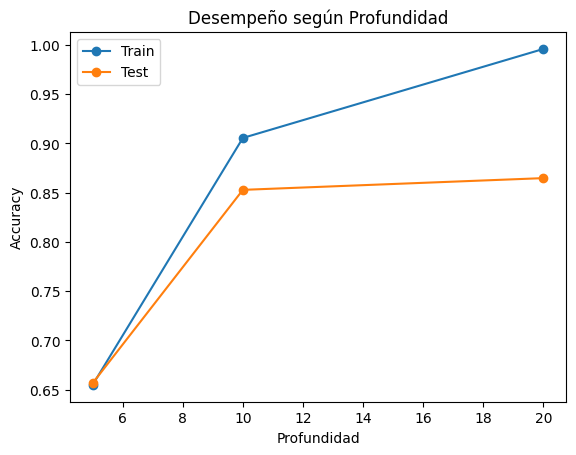

In [5]:
# 8. Gráfica de desempeño
plt.plot(df_res['Profundidad'], df_res['Train'], label='Train', marker='o')
plt.plot(df_res['Profundidad'], df_res['Test'], label='Test', marker='o')
plt.xlabel('Profundidad')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Desempeño según Profundidad')
plt.show()

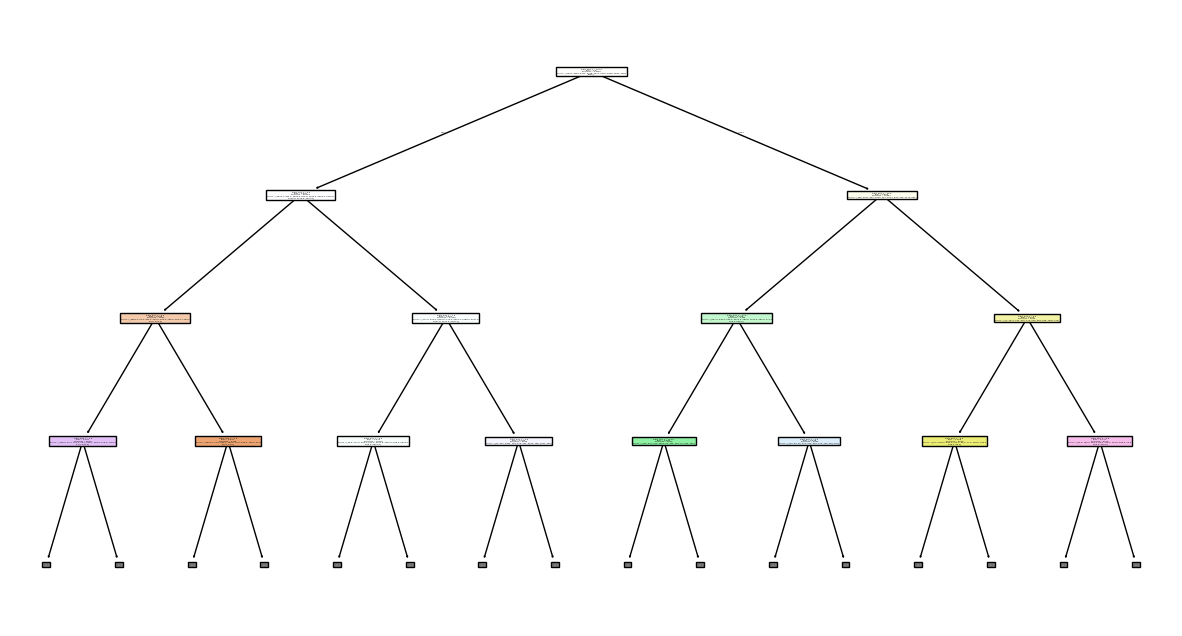

In [6]:
# 9. Árbol de decisión simple
clf_simple = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_simple.fit(X_train, y_train)

plt.figure(figsize=(15, 8))
plot_tree(clf_simple, max_depth=3, filled=True, feature_names=X.columns.tolist())
plt.show()